<a href="https://colab.research.google.com/github/SanaAlotaibi/DataScienceProject/blob/main/IT362_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


In [9]:
df = pd.read_csv("CleanedDataset.csv")

print(" Dataset Loaded Successfully!")
df.head()


 Dataset Loaded Successfully!


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [12]:
import pandas as pd
df = pd.read_csv("CleanedDataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(5109, 12)
['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [13]:
import re

def normalize(col):
    col = col.strip().lower()
    col = re.sub(r'[\s\-]+', '_', col)      # مسافات/شرطات -> _
    col = re.sub(r'[^0-9a-zA-Z_]+', '', col)
    return col

df.columns = [normalize(c) for c in df.columns]
print(df.columns.tolist())


['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


In [14]:
# دوال مساعدة لاختيار أول عمود يطابق أي مرشح
def pick(colnames, candidates):
    for c in colnames:
        for cand in candidates:
            if cand in c:
                return c
    return None

cols = df.columns.tolist()

stars_col  = pick(cols, ["stargazers_count","stars","stargazers"])
forks_col  = pick(cols, ["forks_count","forks"])
lang_col   = pick(cols, ["primary_language","language","lang"])
year_col   = pick(cols, ["created_year","year"])  # قد ما يكون موجود

created_at_col = pick(cols, ["created_at","created_date","created"])  # بديل لاستخراج السنة إن ما وُجد year

print("stars_col :", stars_col)
print("forks_col :", forks_col)
print("lang_col  :", lang_col)
print("year_col  :", year_col)
print("created_at_col :", created_at_col)


stars_col : stars
forks_col : forks
lang_col  : primary_language
year_col  : None
created_at_col : created_at


In [15]:
import numpy as np

if (year_col is None) and (created_at_col is not None):
    df['created_year'] = pd.to_datetime(df[created_at_col], errors='coerce').dt.year
    year_col = 'created_year'

# تحويل أعمدة النجوم/الفورك لأرقام لو كانت نصوص
for c in [stars_col, forks_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [16]:
required = [stars_col, forks_col, year_col, lang_col]
if any(x is None for x in required):
    missing = [n for n,x in zip(["stars","forks","year","language"], required) if x is None]
    raise ValueError(f"Couldn't find needed columns: {missing}. Please show df.columns so we map them manually.")

# تخلص من الصفوف الناقصة
use_df = df[[stars_col, forks_col, year_col, lang_col]].dropna().copy()
use_df.head()


,stars,forks,created_year,primary_language
0,40213.0,4564.0,2020.0,Python
1,28016.0,3470.0,2020.0,Python
2,23807.0,9161.0,2020.0,Jupyter Notebook
3,21746.0,2236.0,2020.0,Python
4,20687.0,2953.0,2020.0,Python


In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Encode language
enc = LabelEncoder()
use_df['language_encoded'] = enc.fit_transform(use_df[lang_col].fillna('Unknown').astype(str))

# Features + scaling
X = use_df[[stars_col, forks_col, year_col, 'language_encoded']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


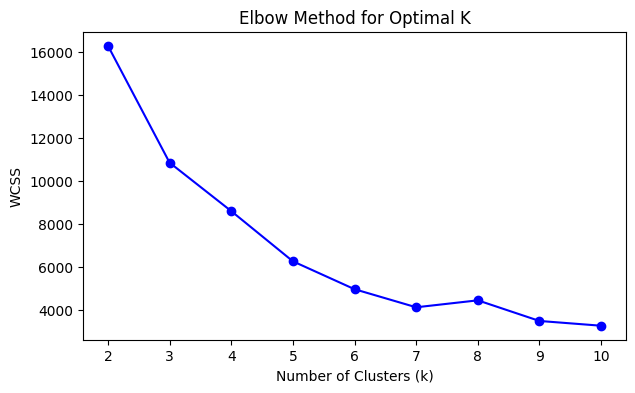

In [18]:
wcss = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, wcss, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()


Silhouette (KMeans): 0.383


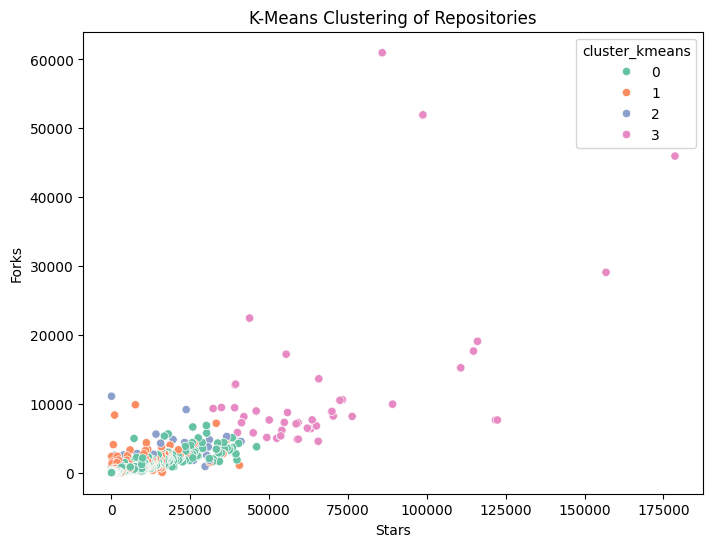

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)
use_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print("Silhouette (KMeans):", round(silhouette_score(X_scaled, use_df['cluster_kmeans']), 3))

plt.figure(figsize=(8,6))
sns.scatterplot(x=use_df[stars_col], y=use_df[forks_col], hue=use_df['cluster_kmeans'], palette='Set2')
plt.title('K-Means Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


Clusters (valid only): 1 | Noise ratio: 1.10%
 DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.


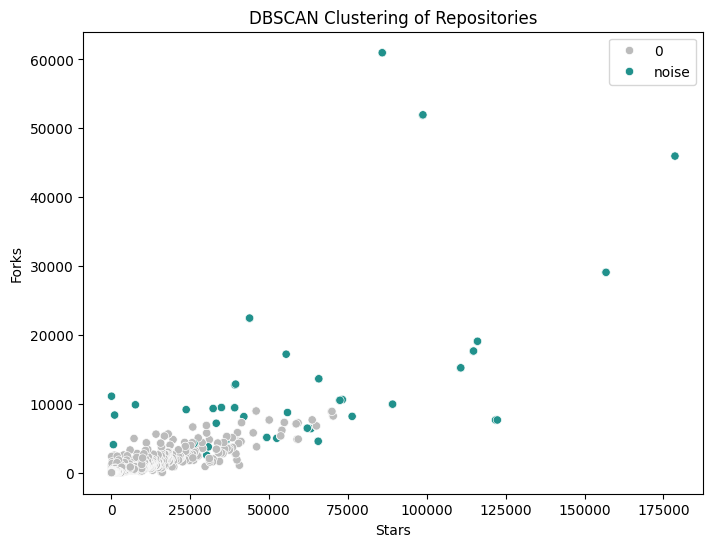

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db = DBSCAN(eps=1.2, min_samples=8)
use_df['cluster_dbscan'] = db.fit_predict(X_scaled)

valid_mask = use_df['cluster_dbscan'] != -1
valid_labels = use_df.loc[valid_mask, 'cluster_dbscan']
n_clusters_valid = valid_labels.nunique()
noise_ratio = 1.0 - valid_mask.mean()

print(f"Clusters (valid only): {n_clusters_valid} | Noise ratio: {noise_ratio:.2%}")

if (valid_mask.sum() > 0) and (n_clusters_valid >= 2):
    sil_db = silhouette_score(X_scaled[valid_mask], valid_labels)
    print(f"Silhouette (DBSCAN): {sil_db:.3f}")
else:
    print(" DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.")

plt.figure(figsize=(8,6))
palette = sns.color_palette("viridis", max(n_clusters_valid, 1))
sns.scatterplot(
    x=use_df[stars_col], y=use_df[forks_col],
    hue=np.where(use_df['cluster_dbscan'] == -1, 'noise', use_df['cluster_dbscan'].astype(str)),
    palette=["#bbbbbb"] + palette if n_clusters_valid > 0 else ["#bbbbbb"],
    legend='full'
)
plt.title('DBSCAN Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


In [24]:
out = use_df.copy()
out.rename(columns={
    stars_col:'Stars',
    forks_col:'Forks',
    year_col:'Created_Year',
    lang_col:'Primary_Language'
}, inplace=True, errors='ignore')

out.to_csv("Clustered_Results.csv", index=False)
print(" Saved to Clustered_Results.csv")


 Saved to Clustered_Results.csv
